In [2]:
import rioxarray as rio

In [ ]:
ashe_tiff = rio.open_rasterio(r"C:\Users\thewe\OneDrive\Documents\GitHub\AES408_notes_inclass_files\files\m_3508228_nw_17_060_20220923.tif").rio.reproject("EPSG:4326")

In [4]:
ashe_tiff[0]

<xarray.DataArray (y: 11395, x: 11676)> Size: 133MB
array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(11395, 11676), dtype=uint8)
Coordinates:
  * y            (y) float64 91kB 35.63 35.63 35.63 35.63 ... 35.56 35.56 35.56
  * x            (x) float64 93kB -82.63 -82.63 -82.63 ... -82.56 -82.56 -82.56
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              255

In [5]:
red = ashe_tiff[0].astype("float32")
green = ashe_tiff[1].astype("float32")
blue = ashe_tiff[2].astype("float32")
nir = ashe_tiff[3].astype("float32")

In [6]:
ndvi = (nir - red)/(nir + red)

In [7]:
ndvi

<xarray.DataArray (y: 11395, x: 11676)> Size: 532MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(11395, 11676), dtype=float32)
Coordinates:
  * y            (y) float64 91kB 35.63 35.63 35.63 35.63 ... 35.56 35.56 35.56
  * x            (x) float64 93kB -82.63 -82.63 -82.63 ... -82.56 -82.56 -82.56
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              255

In [8]:
# remote sensing technique that helps with identifying the white tops of buildings
brightness = (red + green + blue)/3

In [9]:
build_ndvi = (ndvi > -0.1) & (ndvi < 0.1) & (brightness > 200)

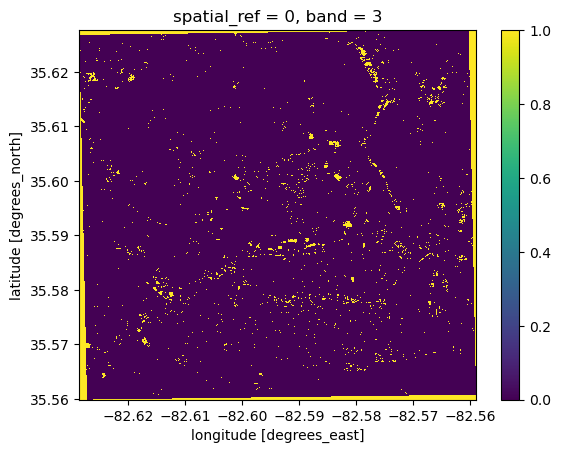

In [10]:
build_ndvi.plot()

c:\Users\thewe\OneDrive\Documents\GitHub\AES408_notes_inclass_files\.pixi\envs\default\Lib\site-packages\skimage\exposure\exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)


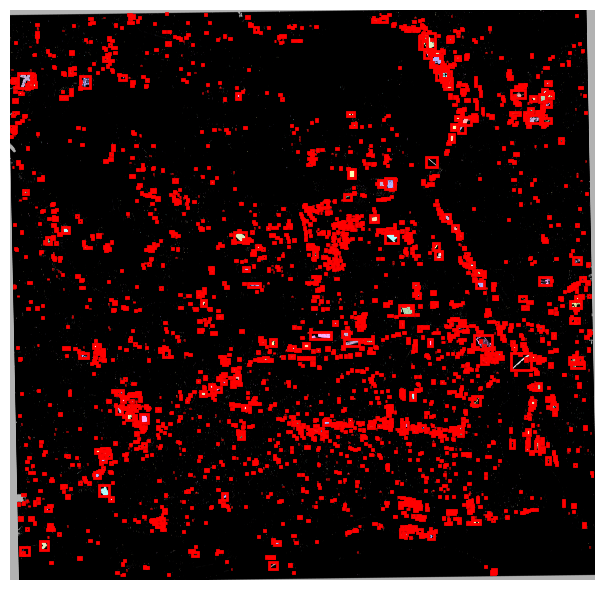

In [11]:
# From scikit-image documentation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from skimage import data
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, footprint_rectangle
from skimage.color import label2rgb


image = build_ndvi.values[50:-50, 50:-50]

# apply threshold
thresh = threshold_otsu(image)
bw = closing(image > thresh, footprint_rectangle((3, 3)))

# remove artifacts connected to image border
cleared = clear_border(bw)

# label image regions
label_image = label(cleared)
# to make the background transparent, pass the value of `bg_label`,
# and leave `bg_color` as `None` and `kind` as `overlay`
image_label_overlay = label2rgb(label_image, image=image, bg_label=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image_label_overlay)

for region in regionprops(label_image):
    # take regions with large enough areas
    if region.area >= 100:
        # draw rectangle around segmented coins
        minr, minc, maxr, maxc = region.bbox
        rect = mpatches.Rectangle(
            (minc, minr),
            maxc - minc,
            maxr - minr,
            fill=False,
            edgecolor='red',
            linewidth=2,
        )
        ax.add_patch(rect)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [16]:
build_ndvi_geometry = build_ndvi.values.astype('uint8')
transform = ashe_tiff.rio.transform()

In [20]:
# aided by built-in LLM in VSCode
from rasterio import features
from shapely.geometry import shape

building_polygons = []
for polygon, value in features.shapes(build_ndvi_geometry, transform=transform):
    if value == 1:
        building_polygons.append(shape(polygon))

In [24]:
import geopandas as gpd
gdf = gpd.GeoDataFrame({"geometry": building_polygons},crs=ashe_tiff.rio.crs)

In [25]:
gdf.to_file(r"C:\Users\thewe\Downloads\building_polygons.shp")